# Leakage-safe temporal robustness report

> Each matrix row measures degradation of a TabPFN system re-contextualized using that row's reference-year data, not degradation of the original pre-2007 context.

Artifact-only notebook. It validates, filters, summarizes, and plots frozen outputs. It performs no model, SAE, target, rule, CAV, gradient, recurrence, bootstrap, or change-point fitting. Anchor views use cosine `0.60` and overlap `0.70`; future-selected sensitivity artifacts remain labeled `selection_scope=post_hoc_future`.

In [1]:
from __future__ import annotations
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from artifact_storage import read_artifact

ARTIFACT_ROOT = Path(os.environ.get('TEMPORAL_ARTIFACT_DIR', 'stats/temporal_robustness'))
HEADLINE_COSINE = 0.60
HEADLINE_OVERLAP = 0.70


## Artifact discovery and validation

In [2]:
def read_json(path: Path):
    with path.open(encoding='utf-8') as handle:
        return json.load(handle)

def resolve_parent(root: Path) -> Path | None:
    direct = root / 'parent_manifest.json'
    if direct.is_file():
        return direct
    candidates = sorted(root.glob('*/parent_manifest.json'), key=lambda path: path.stat().st_mtime)
    return candidates[-1] if candidates else None

PARENT_PATH = resolve_parent(ARTIFACT_ROOT)
parent = read_json(PARENT_PATH) if PARENT_PATH else None
if parent is None:
    print(f'No completed temporal run under {ARTIFACT_ROOT.resolve()}')
else:
    required = {'schema_version', 'estimand', 'successful_experiments', 'skipped_references', 'failed_experiments'}
    missing = required - set(parent)
    if missing:
        raise ValueError(f'Parent manifest missing fields: {sorted(missing)}')
    print('Valid experiments:', len(parent['successful_experiments']))
    display(pd.DataFrame(parent['skipped_references']))
    display(pd.DataFrame(parent['failed_experiments']))


Valid experiments: 27


""


""


## Load normalized artifact tables

In [3]:
def load_tables(parent_manifest):
    tables = {}
    manifests = []
    for entry in parent_manifest.get('successful_experiments', []):
        manifest_path = Path(entry['manifest'])
        if not manifest_path.is_file() and PARENT_PATH:
            manifest_path = PARENT_PATH.parent / f"reference_{entry['reference_year']}" / f"split_{entry['patient_split_seed']}" / 'manifest.json'
        manifest = read_json(manifest_path)
        manifests.append(manifest)
        for name, descriptor in manifest.get('artifacts', {}).items():
            value = read_artifact(manifest_path.parent, descriptor)
            if isinstance(value, list) and (not value or isinstance(value[0], dict)):
                frame = pd.DataFrame(value)
                frame['reference_year'] = frame.get('reference_year', manifest['reference_year'])
                frame['patient_split_seed'] = frame.get('patient_split_seed', manifest['patient_split_seed'])
                tables.setdefault(name, []).append(frame)
    for name, descriptor in parent_manifest.get('aggregate_artifacts', {}).items():
        if name not in tables and PARENT_PATH:
            value = read_artifact(PARENT_PATH.parent, descriptor)
            if isinstance(value, list):
                tables[name] = [pd.DataFrame(value)]
    return manifests, {name: pd.concat(frames, ignore_index=True) for name, frames in tables.items()}

manifests, tables = load_tables(parent) if parent else ([], {})
pd.DataFrame([{'table': name, 'rows': len(frame)} for name, frame in sorted(tables.items())])


/tmp/ipykernel_210994/379190372.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return manifests, {name: pd.concat(frames, ignore_index=True) for name, frames in tables.items()}


,table,rows
0,cavs,1077
1,change_points,18
2,distance_summaries,661
3,factor_families,69984
4,factor_year_metrics,668393
5,functional_diagnostics,27
6,lead_lag,2
7,matched_factors,1332
8,matching_recurrence,940896
9,overlap_percentile_winners,23328


## Cohort/class support and factor-family membership

In [4]:
support = tables.get('performance', pd.DataFrame())
support_columns = [column for column in ['reference_year', 'test_year', 'temporal_distance', 'patient_split_seed', 'cohort_view', 'sample_count', 'patient_count', 'death_count', 'survivor_count', 'failure_reason'] if column in support]
display(support[support_columns] if support_columns else support)
families = tables.get('factor_families', tables.get('family_members', pd.DataFrame()))
display(families)
recurrence = tables.get('matching_recurrence', tables.get('recurrence', pd.DataFrame()))
display(recurrence)


,reference_year,test_year,temporal_distance,patient_split_seed,cohort_view,sample_count,patient_count,death_count,survivor_count,failure_reason
0,2007,2007,0,42,all_comer,236,236,18,218,None
1,2007,2008,1,42,returning_t0,190,190,12,178,None
2,2007,2008,1,42,returning_fitting,1336,1336,116,1220,None
3,2007,2008,1,42,new_entrant,875,875,51,824,None
4,2007,2008,1,42,prior_nonreference_returner,0,0,0,0,insufficient_class_support
...,...,...,...,...,...,...,...,...,...,...
670,2014,2015,1,44,all_comer,2311,2311,97,2214,None
671,2014,2015,1,44,pipeline_unseen,484,484,34,450,None
672,2015,2015,0,42,all_comer,288,288,12,276,None
673,2015,2015,0,43,all_comer,288,288,12,276,None


,activation_percentile,canonical_factor_id,canonical_sae_seed,factor_family_uid,match_score,matching_criterion,matching_threshold,member_factor_id,member_sae_seed,patient_split_seed,reference_year
0,NaN,0,42,2007/42/42/0,1.000000,canonical_identity,None,0,42,42,2007
1,NaN,0,42,2007/42/42/0,0.184354,cosine,None,182,43,42,2007
2,70.0,0,42,2007/42/42/0,0.166667,overlap,None,89,43,42,2007
3,80.0,0,42,2007/42/42/0,0.166667,overlap,None,243,43,42,2007
4,90.0,0,42,2007/42/42/0,0.500000,overlap,None,29,43,42,2007
...,...,...,...,...,...,...,...,...,...,...,...
69979,90.0,287,42,2015/44/42/287,0.944444,overlap,None,5,43,44,2015
69980,NaN,287,42,2015/44/42/287,0.994474,cosine,None,28,44,44,2015
69981,70.0,287,42,2015/44/42/287,0.930233,overlap,None,28,44,44,2015
69982,80.0,287,42,2015/44/42/287,0.965517,overlap,None,28,44,44,2015


,canonical_factor_id,comparison_count,cosine_threshold,factor_family_uid,matching_view,overlap_percentile,overlap_threshold,pass_count,recurrence,recurrent,reference_year,patient_split_seed
0,0,2,0.5,2007/42/42/0,cosine_qualified,NaN,NaN,0,0.0,False,2007,42
1,0,2,0.6,2007/42/42/0,cosine_qualified,NaN,NaN,0,0.0,False,2007,42
2,0,2,0.7,2007/42/42/0,cosine_qualified,NaN,NaN,0,0.0,False,2007,42
3,0,2,0.8,2007/42/42/0,cosine_qualified,NaN,NaN,0,0.0,False,2007,42
4,0,2,NaN,2007/42/42/0,overlap_qualified,70.0,0.6,0,0.0,False,2007,42
...,...,...,...,...,...,...,...,...,...,...,...,...
940891,287,2,0.8,2015/44/42/287,cosine_exclusive,90.0,0.7,0,0.0,False,2015,44
940892,287,2,0.8,2015/44/42/287,overlap_exclusive,90.0,0.7,0,0.0,False,2015,44
940893,287,2,0.8,2015/44/42/287,intersection,90.0,0.8,2,1.0,True,2015,44
940894,287,2,0.8,2015/44/42/287,cosine_exclusive,90.0,0.8,0,0.0,False,2015,44


In [8]:
support[support_columns].head(18)

,reference_year,test_year,temporal_distance,patient_split_seed,cohort_view,sample_count,patient_count,death_count,survivor_count,failure_reason
0,2007,2007,0,42,all_comer,236,236,18,218,None
1,2007,2008,1,42,returning_t0,190,190,12,178,None
2,2007,2008,1,42,returning_fitting,1336,1336,116,1220,None
3,2007,2008,1,42,new_entrant,875,875,51,824,None
4,2007,2008,1,42,prior_nonreference_returner,0,0,0,0,insufficient_class_support
5,2007,2008,1,42,all_comer,2401,2401,179,2222,None
6,2007,2008,1,42,pipeline_unseen,1065,1065,63,1002,None
7,2007,2009,2,42,returning_t0,175,175,16,159,None
8,2007,2009,2,42,returning_fitting,1161,1161,98,1063,None
9,2007,2009,2,42,new_entrant,1163,1163,105,1058,None


In [9]:
recurrence['recurrent'].value_counts()

recurrent
False    897576
True      43320
Name: count, dtype: int64

## Complete primary and secondary rules

In [10]:
rules = tables.get('rules', pd.DataFrame())
rule_columns = [column for column in ['reference_year', 'patient_split_seed', 'factor_family_uid', 'member_sae_seed', 'rule_source', 'activation_target', 'compatibility_H', 'cutoff', 'rule_text', 'precision', 'recall', 'f2', 'lift', 'target_prevalence', 'prediction_prevalence', 'cohort_size', 'geometric_factor_recurrence', 'semantic_family_recurrence', 'target_role', 'valid', 'failure_reason'] if column in rules]
display(rules[rule_columns] if rule_columns else rules)


,reference_year,patient_split_seed,factor_family_uid,member_sae_seed,rule_source,activation_target,compatibility_H,cutoff,rule_text,precision,recall,f2,lift,target_prevalence,prediction_prevalence,cohort_size,semantic_family_recurrence,target_role,valid,failure_reason
0,2007,42,2007/42/42/1,42,semantic,0.1,90.0,0.242606,"{""rules"": [], ""threshold_name"": ""top_10pct_pos...",0.0,0.0,0.0,0.0,0.004219,0.0,237.0,0.0,secondary,False,insufficient_high_activation_targets
1,2007,42,2007/42/42/1,42,semantic,0.3,70.0,0.072244,"{""rules"": [], ""threshold_name"": ""top_30pct_pos...",0.0,0.0,0.0,0.0,0.016878,0.0,237.0,0.0,secondary,False,insufficient_high_activation_targets
2,2007,42,2007/42/42/1,42,semantic,0.5,50.0,0.020781,"{""rules"": [], ""threshold_name"": ""top_50pct_pos...",0.0,0.0,0.0,0.0,0.042194,0.0,237.0,0.0,secondary,False,insufficient_high_activation_targets
3,2007,42,2007/42/42/2,42,semantic,0.1,90.0,0.085160,"{""rules"": [], ""threshold_name"": ""top_10pct_pos...",0.0,0.0,0.0,0.0,0.008439,0.0,237.0,0.0,secondary,False,insufficient_high_activation_targets
4,2007,42,2007/42/42/2,42,semantic,0.3,70.0,0.050039,"{""rules"": [], ""threshold_name"": ""top_30pct_pos...",0.0,0.0,0.0,0.0,0.021097,0.0,237.0,0.0,secondary,False,insufficient_high_activation_targets
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61885,2015,44,2015/44/42/61,44,high_precision,0.3,70.0,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,secondary,False,no_valid_reference_candidate
61886,2015,44,2015/44/42/61,44,high_precision,0.5,50.0,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,secondary,False,no_valid_reference_candidate
61887,2015,44,2015/44/42/106,44,high_precision,0.1,90.0,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,secondary,False,no_valid_reference_candidate
61888,2015,44,2015/44/42/106,44,high_precision,0.3,70.0,NaN,None,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,secondary,False,no_valid_reference_candidate


In [11]:
# rules[rules['valid'] == False].groupby('failure_reason').size().sort_values(ascending=False).rename('count').reset_index()
rules[rule_columns][rules['valid'] == True]

,reference_year,patient_split_seed,factor_family_uid,member_sae_seed,rule_source,activation_target,compatibility_H,cutoff,rule_text,precision,recall,f2,lift,target_prevalence,prediction_prevalence,cohort_size,semantic_family_recurrence,target_role,valid,failure_reason
1216,2007,42,2007/42/42/3,42,high_precision,0.3,70.0,1.965742,EVENT_c2MED_ERITRO > 1.50 AND EVENT_C1DIALISE...,0.916667,0.647059,0.687500,12.779412,0.071730,0.050633,237.0,NaN,primary,True,None
1394,2007,42,2007/42/42/111,42,high_precision,0.5,50.0,0.789636,DIAGN_N189 > 0.50 AND EVENT_c2MED_CALCI > 1.50,0.923077,0.307692,0.355030,5.609467,0.164557,0.054852,237.0,NaN,primary,True,None
1436,2007,42,2007/42/42/135,42,high_precision,0.5,50.0,10.274088,EVENT_c3ACESSO_CT > 1.00 AND EVENT_C1DIALISE_...,0.900000,0.290323,0.335821,6.880645,0.130802,0.042194,237.0,NaN,primary,True,None
1447,2007,42,2007/42/42/139,42,high_precision,0.3,70.0,5.361951,EVENT_c2MED_AZA > 0.50,0.909091,0.500000,0.549451,5.386364,0.168776,0.092827,237.0,NaN,primary,True,None
1448,2007,42,2007/42/42/139,42,high_precision,0.5,50.0,4.102198,EVENT_c2MED_AZA > 0.50,0.909091,0.298507,0.344828,3.215739,0.282700,0.092827,237.0,NaN,secondary,True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61582,2015,44,2015/44/42/218,44,high_precision,0.3,70.0,1.754954,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,0.961538,0.961538,0.961538,10.687870,0.089965,0.089965,289.0,NaN,primary,True,None
61583,2015,44,2015/44/42/218,44,high_precision,0.5,50.0,0.705920,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1.000000,0.634146,0.684211,7.048780,0.141869,0.089965,289.0,NaN,secondary,True,None
61726,2015,44,2015/44/42/25,44,high_precision,0.3,70.0,9.870797,EVENT_c2MED_ERITRO > 7.50 AND EVENT_C1DIALISE...,0.923077,0.352941,0.402685,7.846154,0.117647,0.044983,289.0,NaN,secondary,True,None
61727,2015,44,2015/44/42/25,44,high_precision,0.5,50.0,7.653079,DIAGN_N180 > 8.50 AND EVENT_C1DIALISE_HD > 7...,0.958333,0.377049,0.429104,4.540301,0.211073,0.083045,289.0,NaN,primary,True,None


## Semantic selection diagnostics and long-rule review

The selection funnel assigns each factor-target attempt to one mutually exclusive terminal stage, so those counts sum to the number of attempts. Leave-one-criterion-out rescue flags are counterfactual and may overlap: one excluded attempt can be rescued by relaxing more than one criterion, so ablation counts must not be summed.

In [ ]:
semantic_diagnostics = tables.get('semantic_selection_diagnostics', pd.DataFrame())
semantic_summary = tables.get('semantic_selection_summary', pd.DataFrame())

if semantic_diagnostics.empty and semantic_summary.empty:
    print('Semantic selection diagnostics are not present in this artifact set (expected for legacy runs).')
else:
    if not semantic_summary.empty:
        print('Artifact-provided semantic selection summary')
        display(semantic_summary)

    if not semantic_diagnostics.empty:
        stage_column = next((column for column in ('funnel_stage', 'terminal_stage', 'selection_stage', 'outcome', 'failure_stage', 'failure_reason') if column in semantic_diagnostics), None)
        factor_column = next((column for column in ('factor_family_uid', 'factor_uid', 'factor_id') if column in semantic_diagnostics), None)
        available_groups = [column for column in ('reference_year', 'activation_target') if column in semantic_diagnostics]
        rescue_columns = [column for column in semantic_diagnostics if column.startswith(('rescued_without_', 'rescued_by_')) or column.endswith('_rescue')]

        if stage_column is None:
            print('Diagnostics table loaded, but no recognized terminal-stage column was found.')
            display(semantic_diagnostics.head())
        else:
            funnel_views = []
            for group_columns, view_name in [([], 'overall')] + [([column], f'by_{column}') for column in available_groups]:
                funnel = (
                    semantic_diagnostics.groupby(group_columns + [stage_column], dropna=False)
                    .size().rename('factor_target_attempts').reset_index()
                )
                if group_columns:
                    denominators = (
                        semantic_diagnostics.groupby(group_columns, dropna=False)
                        .size().rename('attempt_denominator').reset_index()
                    )
                    funnel = funnel.merge(denominators, on=group_columns, how='left')
                else:
                    funnel['attempt_denominator'] = len(semantic_diagnostics)
                funnel['attempt_rate'] = funnel['factor_target_attempts'] / funnel['attempt_denominator']
                if factor_column:
                    distinct = (
                        semantic_diagnostics.groupby(group_columns + [stage_column], dropna=False)[factor_column]
                        .nunique().rename('distinct_factors').reset_index()
                    )
                    funnel = funnel.merge(distinct, on=group_columns + [stage_column], how='left')
                funnel.insert(0, 'summary_view', view_name)
                funnel_views.append(funnel)
            print('Exclusive terminal-stage funnel (denominator: factor-target attempts within each displayed view/group)')
            display(pd.concat(funnel_views, ignore_index=True))

        if rescue_columns:
            ablation_frame = semantic_diagnostics
            if 'ablation_eligible' in ablation_frame:
                ablation_frame = ablation_frame.loc[ablation_frame['ablation_eligible'].fillna(False).astype(bool)]
            rescue_views = []
            for group_columns, view_name in [([], 'overall')] + [([column], f'by_{column}') for column in available_groups]:
                id_columns = group_columns + ([factor_column] if factor_column else [])
                rescue_long = ablation_frame.melt(
                    id_vars=id_columns, value_vars=rescue_columns,
                    var_name='relaxed_criterion', value_name='rescued',
                )
                rescue_long['rescued'] = rescue_long['rescued'].fillna(False).astype(bool)
                rescue_summary = (
                    rescue_long.groupby(group_columns + ['relaxed_criterion'], dropna=False)['rescued']
                    .agg(rescued_attempts='sum', attempt_denominator='size').reset_index()
                )
                rescue_summary['rescue_rate'] = rescue_summary['rescued_attempts'] / rescue_summary['attempt_denominator']
                if factor_column:
                    rescued_distinct = (
                        rescue_long.loc[rescue_long['rescued']]
                        .groupby(group_columns + ['relaxed_criterion'], dropna=False)[factor_column]
                        .nunique().rename('rescued_distinct_factors').reset_index()
                    )
                    denominator_distinct = (
                        rescue_long.groupby(group_columns + ['relaxed_criterion'], dropna=False)[factor_column]
                        .nunique().rename('distinct_factor_denominator').reset_index()
                    )
                    rescue_summary = rescue_summary.merge(rescued_distinct, on=group_columns + ['relaxed_criterion'], how='left')
                    rescue_summary = rescue_summary.merge(denominator_distinct, on=group_columns + ['relaxed_criterion'], how='left')
                    rescue_summary['rescued_distinct_factors'] = rescue_summary['rescued_distinct_factors'].fillna(0).astype(int)
                    rescue_summary['distinct_factor_rescue_rate'] = rescue_summary['rescued_distinct_factors'] / rescue_summary['distinct_factor_denominator']
                rescue_summary.insert(0, 'summary_view', view_name)
                rescue_views.append(rescue_summary)
            print('Overlapping leave-one-criterion-out rescues (each criterion uses the same factor-target denominator)')
            display(pd.concat(rescue_views, ignore_index=True))
        elif not semantic_diagnostics.empty:
            print('No leave-one-criterion-out rescue columns were found in the diagnostics table.')

In [ ]:
def semantic_rule_shape(rule_text):
    try:
        payload = json.loads(rule_text) if isinstance(rule_text, str) else rule_text
    except (TypeError, json.JSONDecodeError):
        return pd.Series({'condition_counts_per_rule': [], 'max_conditions_in_rule': np.nan, 'has_rule_over_5_conditions': False, 'rule_shape_parse_error': True})
    if isinstance(payload, dict):
        conjunctive_rules = payload.get('rules', [])
    elif isinstance(payload, list):
        conjunctive_rules = payload
    else:
        conjunctive_rules = []
    condition_counts = [len(rule.get('conditions', [])) for rule in conjunctive_rules if isinstance(rule, dict)]
    maximum = max(condition_counts) if condition_counts else 0
    return pd.Series({
        'condition_counts_per_rule': condition_counts,
        'max_conditions_in_rule': maximum,
        'has_rule_over_5_conditions': maximum > 5,
        'rule_shape_parse_error': False,
    })

if rules.empty or 'rule_text' not in rules or 'rule_source' not in rules:
    print('No rule table with semantic rule text is available.')
else:
    valid_mask = rules['valid'].fillna(False).astype(bool) if 'valid' in rules else pd.Series(True, index=rules.index)
    selected_semantic_rules = rules.loc[rules['rule_source'].eq('semantic') & valid_mask & rules['rule_text'].notna()].copy()
    if selected_semantic_rules.empty:
        print('No selected semantic rules are available in this artifact set.')
    else:
        selected_semantic_rules = selected_semantic_rules.join(selected_semantic_rules['rule_text'].apply(semantic_rule_shape))
        length_counts = (
            selected_semantic_rules['condition_counts_per_rule'].explode()
            .dropna().astype(int).value_counts().sort_index()
            .rename_axis('conditions_in_conjunctive_rule').rename('selected_rule_count').reset_index()
        )
        print('Condition-length distribution across conjunctive rules in selected semantic rule sets')
        display(length_counts)
        flag_counts = (
            selected_semantic_rules['has_rule_over_5_conditions'].value_counts(dropna=False)
            .rename_axis('has_rule_over_5_conditions').rename('selected_rule_set_count').reset_index()
        )
        display(flag_counts)

        long_rule_review = selected_semantic_rules.loc[
            selected_semantic_rules['max_conditions_in_rule'].between(6, 10, inclusive='both')
        ]
        review_columns = [column for column in (
            'reference_year', 'patient_split_seed', 'factor_family_uid', 'member_sae_seed',
            'activation_target', 'target_role', 'condition_counts_per_rule',
            'max_conditions_in_rule', 'has_rule_over_5_conditions', 'rule_text',
        ) if column in long_rule_review]
        sort_columns = [column for column in ('reference_year', 'patient_split_seed', 'factor_family_uid', 'activation_target') if column in review_columns]
        long_rule_review = long_rule_review[review_columns]
        if sort_columns:
            long_rule_review = long_rule_review.sort_values(sort_columns)
        print(f'Selected semantic rule sets containing a 6-10-condition conjunctive rule: {len(long_rule_review)}')
        display(long_rule_review.reset_index(drop=True))

## Anchor matrices and artifact-backed sensitivity selectors

test_year,2007,2008,2009,2010,2011,2012,2013,2014,2015
reference_year,,,,,,,,,
2007,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2008,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2009,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2010,nan,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2011,nan,nan,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000
2012,nan,nan,nan,nan,nan,3.000000,3.000000,3.000000,3.000000
2013,nan,nan,nan,nan,nan,nan,3.000000,3.000000,3.000000
2014,nan,nan,nan,nan,nan,nan,nan,3.000000,3.000000
2015,nan,nan,nan,nan,nan,nan,nan,nan,3.000000


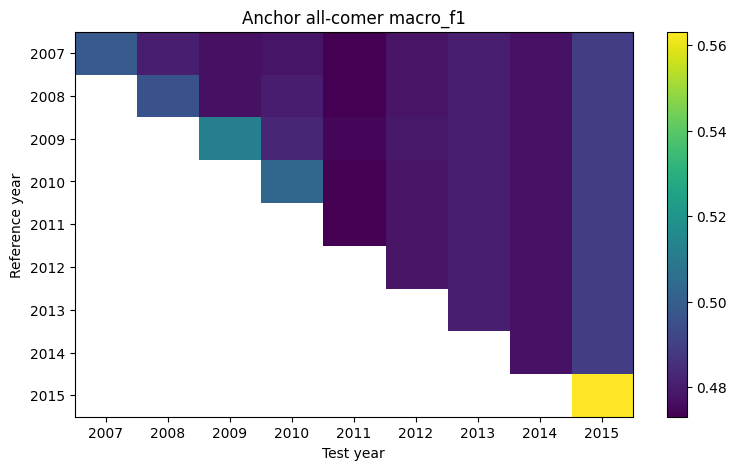

test_year,2007,2008,2009,2010,2011,2012,2013,2014,2015
reference_year,,,,,,,,,
2007,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2008,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2009,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2010,nan,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
2011,nan,nan,nan,nan,3.000000,3.000000,3.000000,3.000000,3.000000
2012,nan,nan,nan,nan,nan,3.000000,3.000000,3.000000,3.000000
2013,nan,nan,nan,nan,nan,nan,3.000000,3.000000,3.000000
2014,nan,nan,nan,nan,nan,nan,nan,3.000000,3.000000
2015,nan,nan,nan,nan,nan,nan,nan,nan,3.000000


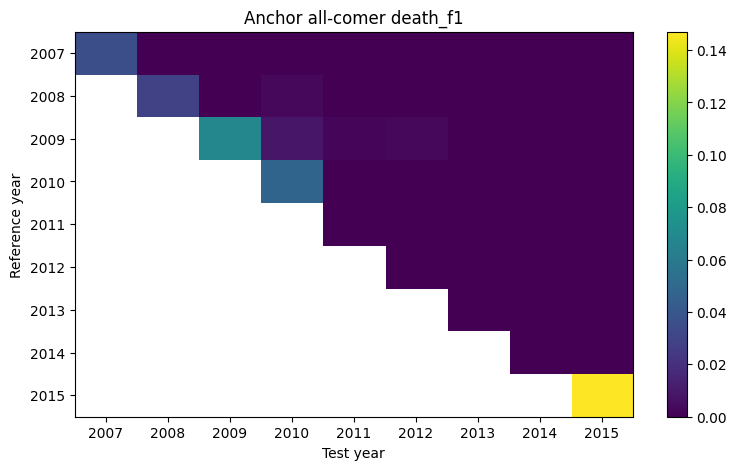

In [6]:
def select_view(frame, *, cohort='all_comer', matching_view='cosine_qualified', cosine=HEADLINE_COSINE, overlap=HEADLINE_OVERLAP, rule_source=None):
    selected = frame.copy()
    filters = {'cohort_view': cohort, 'matching_view': matching_view, 'cosine_threshold': cosine, 'overlap_threshold': overlap}
    if rule_source is not None:
        filters['rule_source'] = rule_source
    for column, value in filters.items():
        if column in selected and value is not None:
            selected = selected[selected[column].eq(value)]
    return selected

def plot_triangular(frame, metric, title):
    if frame.empty or not {'reference_year', 'test_year', metric}.issubset(frame):
        print(f'Unavailable: {metric}')
        return
    matrix = frame.pivot_table(index='reference_year', columns='test_year', values=metric, aggfunc='mean')
    support_matrix = frame.pivot_table(index='reference_year', columns='test_year', values=metric, aggfunc='count')
    display(support_matrix.style.set_caption(f'{title} support'))
    fig, axis = plt.subplots(figsize=(9, 5))
    image = axis.imshow(matrix.to_numpy(float), aspect='auto')
    axis.set(title=title, xlabel='Test year', ylabel='Reference year', xticks=range(len(matrix.columns)), yticks=range(len(matrix.index)), xticklabels=matrix.columns, yticklabels=matrix.index)
    fig.colorbar(image, ax=axis)
    plt.show()

anchor_performance = select_view(support)
for metric in ('macro_f1', 'death_f1'):
    plot_triangular(anchor_performance, metric, f'Anchor all-comer {metric}')


## Temporal-distance summaries, uncertainty, lead-lag, and exploratory change points

In [7]:
for name in ('distance_summaries', 'uncertainty', 'lead_lag', 'change_points'):
    frame = tables.get(name, pd.DataFrame())
    if not frame.empty and 'selection_scope' in frame:
        post_hoc = frame['selection_scope'].eq('post_hoc_future')
        if post_hoc.any():
            print(f'{name}: {int(post_hoc.sum())} post-hoc future sensitivity rows')
    display(frame)
trajectories = tables.get('factor_year_metrics', pd.DataFrame())
if not trajectories.empty and 'factor_count' in trajectories:
    display(trajectories[trajectories['factor_count'] < 10].assign(exploratory=True))


,cohort_view,count,lower_95,mean,median,metric,source,std,temporal_distance,upper_95,rule_source,target_role
0,all_comer,27,0.473244,0.497870,0.480707,macro_f1,performance,0.031074,0,0.567154,NaN,NaN
1,all_comer,27,0.000000,0.036328,0.000000,death_f1,performance,0.055887,0,0.153846,NaN,NaN
2,returning_t0,21,0.463741,0.482356,0.482759,macro_f1,performance,0.012500,1,0.508797,NaN,NaN
3,returning_t0,21,0.000000,0.004535,0.000000,death_f1,performance,0.020783,1,0.047619,NaN,NaN
4,returning_fitting,24,0.470242,0.480055,0.479386,macro_f1,performance,0.005793,1,0.491553,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
656,returning_fitting,198,0.000000,0.000000,0.000000,tcav,tcav,0.000000,6,0.000000,semantic,secondary
657,new_entrant,198,0.000000,0.000000,0.000000,tcav,tcav,0.000000,6,0.000000,semantic,secondary
658,prior_nonreference_returner,198,0.000000,0.000000,0.000000,tcav,tcav,0.000000,6,0.000000,semantic,secondary
659,all_comer,198,0.000000,0.000000,0.000000,tcav,tcav,0.000000,6,0.000000,semantic,secondary


,cohort_view,lower_95,metric,reference_year,resampling_unit,test_year,upper_95,valid_repetition_count,activation_target,exploratory,rule_source,target_role
0,all_comer,0.480176,macro_f1,2007,patient_split,2007,0.533868,3,NaN,NaN,NaN,NaN
1,all_comer,0.000000,death_f1,2007,patient_split,2007,0.105263,3,NaN,NaN,NaN,NaN
2,returning_t0,0.483461,macro_f1,2007,patient_split,2008,0.483696,2,NaN,NaN,NaN,NaN
3,returning_t0,0.000000,death_f1,2007,patient_split,2008,0.000000,2,NaN,NaN,NaN,NaN
4,returning_fitting,0.476041,macro_f1,2007,patient_split,2008,0.477308,3,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4835,all_comer,1.000000,prevalence_ratio,2015,patient_split_then_sae_member,2015,1.000000,28,0.1,True,high_precision,secondary
4836,all_comer,0.152015,f2,2015,patient_split_then_sae_member,2015,0.488450,236,0.3,True,high_precision,secondary
4837,all_comer,1.000000,prevalence_ratio,2015,patient_split_then_sae_member,2015,1.000000,236,0.3,True,high_precision,secondary
4838,all_comer,0.458149,f2,2015,patient_split_then_sae_member,2015,0.624706,124,0.3,True,semantic,primary


,cluster_count,cohort_view,concept_metric,control_coefficients,exploratory,failure_reason,lag,lag_coefficient,lag_coefficient_lower_95,lag_coefficient_upper_95,matching_view,row_count,rule_source,valid
0,24,all_comer,prevalence_degradation,{'contemporaneous_concept_degradation': 0.0056...,True,None,1,-0.007719,-0.018255,0.002579,union,108,semantic,True
1,21,all_comer,prevalence_degradation,{'contemporaneous_concept_degradation': 0.0001...,True,None,2,-0.001686,-0.007909,0.004224,union,84,semantic,True


,bic_improvement,breakpoint,exploratory,metric,no_break_bic,reference_year,segmented_bic,segmented_preferred,sustained_crossing,valid,failure_reason
0,10.300586,2.0,True,macro_f1,-84.891452,2007,-95.192038,True,NaN,True,NaN
1,6.609720,3.0,True,macro_f1,-75.551872,2008,-82.161591,True,NaN,True,NaN
2,10.797852,2.0,True,macro_f1,-59.780414,2009,-70.578266,True,NaN,True,NaN
3,3.252665,2.0,True,macro_f1,-52.233793,2010,-55.486458,True,NaN,True,NaN
4,-1.446082,2.0,True,macro_f1,-55.140500,2011,-53.694418,False,NaN,True,NaN
5,NaN,NaN,NaN,macro_f1,NaN,2012,NaN,NaN,NaN,False,insufficient_segmented_observations
6,NaN,NaN,NaN,macro_f1,NaN,2013,NaN,NaN,NaN,False,insufficient_segmented_observations
7,NaN,NaN,NaN,macro_f1,NaN,2014,NaN,NaN,NaN,False,insufficient_segmented_observations
8,NaN,NaN,NaN,macro_f1,NaN,2015,NaN,NaN,NaN,False,insufficient_segmented_observations
9,4.069376,2.0,True,prevalence_ratio,-36.014534,2007,-40.083911,True,1.0,True,NaN
